In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data_Preparation


In [2]:
import os

BASE = '/content/drive/MyDrive/Recommendation System'

for folder in [
    f'{BASE}/data/raw',
    f'{BASE}/data/processed',
    f'{BASE}/models',
    f'{BASE}/evaluation',
    f'{BASE}/outputs',
    f'{BASE}/notebooks',
]:
    os.makedirs(folder, exist_ok=True)

print('✅ Folder structure ready.')
print(f'Base path: {BASE}')

✅ Folder structure ready.
Base path: /content/drive/MyDrive/Recommendation System


## Install & Import Libraries

In [3]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('✅ Libraries imported.')

✅ Libraries imported.


In [4]:
import urllib.request
import zipfile

RAW_DIR = f'{BASE}/data/raw'
ZIP_PATH = f'{RAW_DIR}/ml-1m.zip'

if not os.path.exists(f'{RAW_DIR}/ml-1m/ratings.dat'):
    print('Downloading MovieLens 1M...')
    url = 'https://files.grouplens.org/datasets/movielens/ml-1m.zip'
    urllib.request.urlretrieve(url, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(RAW_DIR)
    print('✅ Download complete.')
else:
    print('✅ Data already downloaded.')

ML_DIR = f'{RAW_DIR}/ml-1m'

✅ Download complete.


## Load Raw Data

In [5]:
# Load ratings
ratings = pd.read_csv(
    f'{ML_DIR}/ratings.dat',
    sep='::',
    names=['user_id', 'movie_id', 'rating', 'timestamp'],
    engine='python',
    encoding='latin-1'
)

# Load movies
movies = pd.read_csv(
    f'{ML_DIR}/movies.dat',
    sep='::',
    names=['movie_id', 'title', 'genres'],
    engine='python',
    encoding='latin-1'
)

print(f'Total ratings: {len(ratings):,}')
print(f'Total users:   {ratings.user_id.nunique():,}')
print(f'Total movies:  {ratings.movie_id.nunique():,}')
print()
print(ratings.head())

Total ratings: 1,000,209
Total users:   6,040
Total movies:  3,706

   user_id  movie_id  rating  timestamp
0        1      1193       5  978300760
1        1       661       3  978302109
2        1       914       3  978301968
3        1      3408       4  978300275
4        1      2355       5  978824291


## Filter & Sample 150K Interactions

In [6]:
# Keep only users with >= 20 interactions (ensures enough data per user)
user_counts = ratings['user_id'].value_counts()
valid_users = user_counts[user_counts >= 20].index
ratings_filtered = ratings[ratings['user_id'].isin(valid_users)].copy()
print(f'After filtering sparse users: {len(ratings_filtered):,} interactions, {ratings_filtered.user_id.nunique():,} users')

# Sample exactly 150,000 interactions with fixed seed
sampled = ratings_filtered.sample(n=150000, random_state=RANDOM_SEED).reset_index(drop=True)

# Re-index user_id and movie_id to be contiguous integers starting from 0
user_encoder = {uid: idx for idx, uid in enumerate(sampled['user_id'].unique())}
item_encoder = {mid: idx for idx, mid in enumerate(sampled['movie_id'].unique())}

sampled['user_idx'] = sampled['user_id'].map(user_encoder)
sampled['item_idx'] = sampled['movie_id'].map(item_encoder)

NUM_USERS = sampled['user_idx'].nunique()
NUM_ITEMS = sampled['item_idx'].nunique()

print(f'\nSampled dataset:')
print(f'  Interactions: {len(sampled):,}')
print(f'  Users: {NUM_USERS:,}')
print(f'  Items: {NUM_ITEMS:,}')

# Save encoders for later use
import json
# reverse maps for decoding
user_decoder = {v: k for k, v in user_encoder.items()}
item_decoder = {v: k for k, v in item_encoder.items()}

with open(f'{BASE}/data/processed/user_encoder.json', 'w') as f:
    json.dump({str(k): v for k, v in user_encoder.items()}, f)
with open(f'{BASE}/data/processed/item_encoder.json', 'w') as f:
    json.dump({str(k): v for k, v in item_encoder.items()}, f)

# Save movies with encoded ids
movies['item_idx'] = movies['movie_id'].map(item_encoder)
movies_sampled = movies[movies['item_idx'].notna()].copy()
movies_sampled['item_idx'] = movies_sampled['item_idx'].astype(int)
movies_sampled.to_csv(f'{BASE}/data/processed/movies.csv', index=False)

print('\n✅ Encoding done and saved.')

After filtering sparse users: 1,000,209 interactions, 6,040 users

Sampled dataset:
  Interactions: 150,000
  Users: 6,022
  Items: 3,390

✅ Encoding done and saved.


## Apply Leave-One-Out Train/Test Split

In [7]:
# Sort by timestamp
sampled_sorted = sampled.sort_values(['user_idx', 'timestamp'])

# Keep only users with AT LEAST 2 interactions
user_counts = sampled_sorted.groupby('user_idx').size()
valid_users = user_counts[user_counts >= 2].index
sampled_sorted = sampled_sorted[sampled_sorted['user_idx'].isin(valid_users)].copy()

print(f'Users with >= 2 interactions: {len(valid_users):,}')
print(f'Interactions after filter: {len(sampled_sorted):,}')

# Hold out the LAST interaction per user as test
test_df  = sampled_sorted.groupby('user_idx').tail(1).copy()
train_df = sampled_sorted.drop(test_df.index).copy()

# Verify
assert set(test_df['user_idx']) == set(train_df['user_idx']), 'Mismatch in user sets!'

print(f'\nTrain interactions : {len(train_df):,}')
print(f'Test  interactions : {len(test_df):,}  (1 per user)')
print(f'Users in train     : {train_df.user_idx.nunique():,}')
print(f'Users in test      : {test_df.user_idx.nunique():,}')

# Update NUM_USERS and NUM_ITEMS to reflect filtered data
NUM_USERS = train_df['user_idx'].nunique()
NUM_ITEMS = sampled_sorted['item_idx'].nunique()
print(f'\nUpdated NUM_USERS: {NUM_USERS:,}')
print(f'Updated NUM_ITEMS: {NUM_ITEMS:,}')

# Save splits
train_df.to_csv(f'{BASE}/data/processed/train.csv', index=False)
test_df.to_csv(f'{BASE}/data/processed/test.csv',   index=False)
sampled_sorted.to_csv(f'{BASE}/data/processed/sampled_150k.csv', index=False)

print('\n✅ Train/test split saved.')

Users with >= 2 interactions: 5,934
Interactions after filter: 149,912

Train interactions : 143,978
Test  interactions : 5,934  (1 per user)
Users in train     : 5,934
Users in test      : 5,934

Updated NUM_USERS: 5,934
Updated NUM_ITEMS: 3,389

✅ Train/test split saved.


## Build Item Popularity (for Novelty Metric)

In [8]:
# Item popularity = fraction of users who interacted with this item
item_interaction_count = train_df.groupby('item_idx').size()
item_popularity = (item_interaction_count / NUM_USERS).to_dict()

# Assign tiny popularity to unseen items
for i in range(NUM_ITEMS):
    if i not in item_popularity:
        item_popularity[i] = 1e-10

import pickle
with open(f'{BASE}/data/processed/item_popularity.pkl', 'wb') as f:
    pickle.dump(item_popularity, f)

print(f'Item popularity computed for {len(item_popularity):,} items.')
print(f'Most popular item interaction fraction: {max(item_popularity.values()):.4f}')
print(f'Least popular item: {min(item_popularity.values()):.6f}')
print('\n✅ Item popularity saved.')

Item popularity computed for 3,390 items.
Most popular item interaction fraction: 0.0834
Least popular item: 0.000000

✅ Item popularity saved.


## Build Train User-Item Sets (for fast negative sampling)

In [9]:
# For each user, store the set of items they interacted with in training
train_user_items = train_df.groupby('user_idx')['item_idx'].apply(set).to_dict()

with open(f'{BASE}/data/processed/train_user_items.pkl', 'wb') as f:
    pickle.dump(train_user_items, f)

print(f'Train user-item sets built for {len(train_user_items):,} users.')
avg_items = np.mean([len(v) for v in train_user_items.values()])
print(f'Average items per user in train: {avg_items:.1f}')
print('\n✅ All preprocessing complete! You can now run RS1 and RS2 notebooks.')

Train user-item sets built for 5,934 users.
Average items per user in train: 24.3

✅ All preprocessing complete! You can now run RS1 and RS2 notebooks.


## Quick EDA Plots

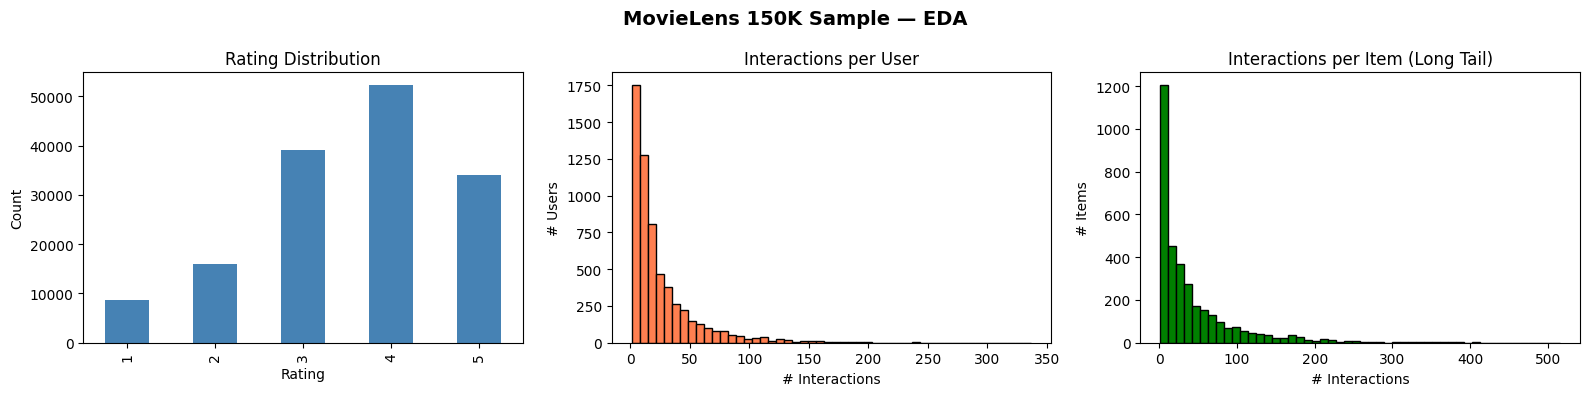

✅ EDA plots saved.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Rating distribution
sampled['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Interactions per user
user_activity = sampled.groupby('user_idx').size()
axes[1].hist(user_activity, bins=50, color='coral', edgecolor='black')
axes[1].set_title('Interactions per User')
axes[1].set_xlabel('# Interactions')
axes[1].set_ylabel('# Users')

# Interactions per item (long tail)
item_activity = sampled.groupby('item_idx').size()
axes[2].hist(item_activity, bins=50, color='green', edgecolor='black')
axes[2].set_title('Interactions per Item (Long Tail)')
axes[2].set_xlabel('# Interactions')
axes[2].set_ylabel('# Items')

plt.suptitle('MovieLens 150K Sample — EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved.')

## Save Dataset Info Summary

In [11]:
dataset_info = {
    'num_users': NUM_USERS,
    'num_items': NUM_ITEMS,
    'num_train': len(train_df),
    'num_test' : len(test_df),
    'random_seed': RANDOM_SEED,
    'split_strategy': 'leave_one_out_by_timestamp'
}

with open(f'{BASE}/data/processed/dataset_info.json', 'w') as f:
    json.dump(dataset_info, f, indent=2)

print('Dataset Info:')
for k, v in dataset_info.items():
    print(f'  {k}: {v}')
print('\n✅ Dataset info saved. Data preparation complete!')

Dataset Info:
  num_users: 5934
  num_items: 3389
  num_train: 143978
  num_test: 5934
  random_seed: 42
  split_strategy: leave_one_out_by_timestamp

✅ Dataset info saved. Data preparation complete!
